In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df=pd.read_csv(r"C:\Users\praga\OneDrive\Desktop\AICW\End to end Linear Reg\End to end Linear Reg\insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [6]:
df.drop_duplicates(inplace=True)
df.shape

(1337, 7)

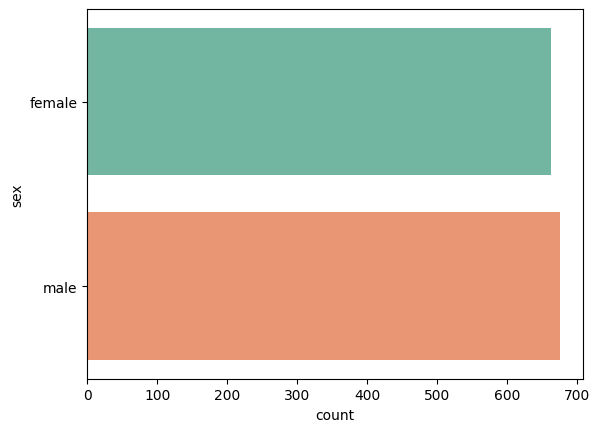

In [7]:
sns.countplot(df['sex'],palette='Set2')
plt.show()

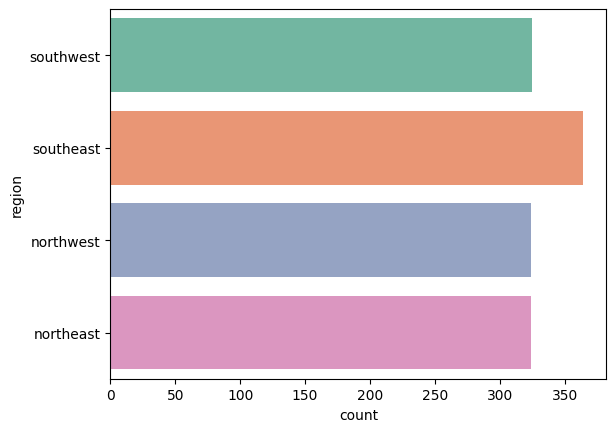

In [8]:
sns.countplot(df['region'],palette='Set2')
plt.show()

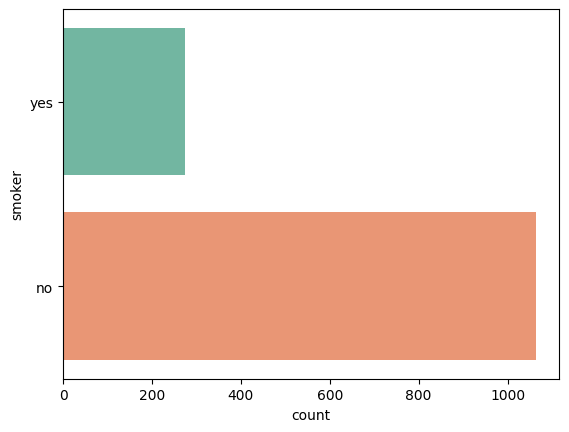

In [9]:
sns.countplot(df['smoker'],palette='Set2')
plt.show()

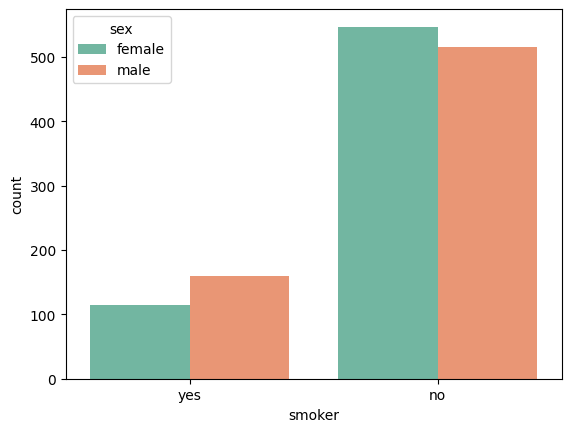

In [10]:
sns.countplot(x="smoker",hue='sex',data=df,palette='Set2')
plt.show()

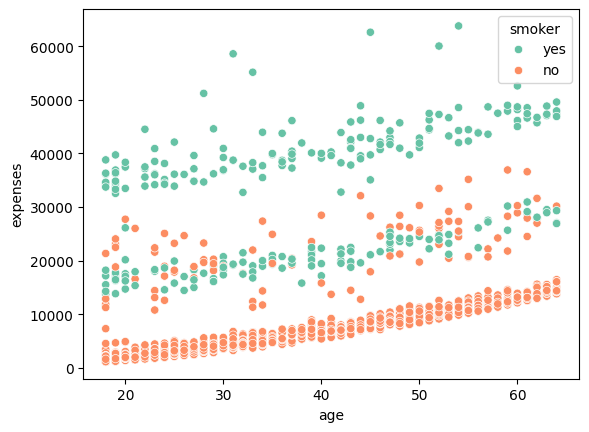

In [11]:
sns.scatterplot(x="age",y="expenses",hue="smoker",data=df,palette='Set2')
plt.show()

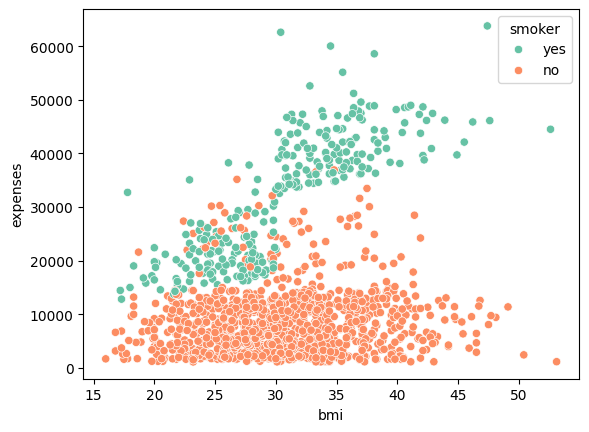

In [12]:
sns.scatterplot(x="bmi",y="expenses",hue="smoker",data=df,palette='Set2')
plt.show()

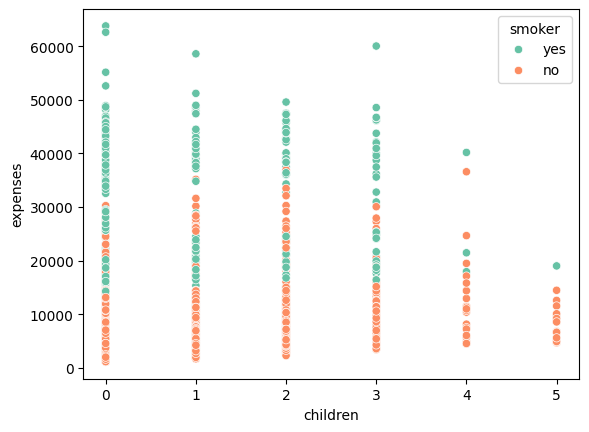

In [13]:
sns.scatterplot(x="children",y="expenses",hue="smoker",data=df,palette='Set2')
plt.show()

In [14]:
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [15]:
#apply onehot encoding by using sklearn
from sklearn.preprocessing import OneHotEncoder

#create a categorical colomn
cat_cols=['sex','smoker','region']

#encoder the categorical columns
encoder=OneHotEncoder(drop='first',sparse_output=False)
encoded_data=encoder.fit_transform(df[cat_cols])


In [16]:
# get the encoded column names
encoded_columns=encoder.get_feature_names_out(cat_cols)
encoded_columns


array(['sex_male', 'smoker_yes', 'region_northwest', 'region_southeast',
       'region_southwest'], dtype=object)

In [17]:
#convert encoded data to dataframe
encoded_df=pd.DataFrame(encoded_data,columns=encoded_columns)
encoded_df.head()


,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,1.0,0.0,0.0
4,1.0,0.0,1.0,0.0,0.0


In [18]:
df_final=pd.concat([df.drop(columns=cat_cols),encoded_df],axis=1)
df_final.head()

,age,bmi,children,expenses,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19.0,27.9,0.0,16884.92,0.0,1.0,0.0,0.0,1.0
1,18.0,33.8,1.0,1725.55,1.0,0.0,0.0,1.0,0.0
2,28.0,33.0,3.0,4449.46,1.0,0.0,0.0,1.0,0.0
3,33.0,22.7,0.0,21984.47,1.0,0.0,1.0,0.0,0.0
4,32.0,28.9,0.0,3866.86,1.0,0.0,1.0,0.0,0.0


In [19]:
df_final.isnull().sum()

age                 1
bmi                 1
children            1
expenses            1
sex_male            1
smoker_yes          1
region_northwest    1
region_southeast    1
region_southwest    1
dtype: int64

In [20]:
df_final.dropna(inplace=True)
df_final.isnull().sum()

age                 0
bmi                 0
children            0
expenses            0
sex_male            0
smoker_yes          0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64

In [21]:
df_final.shape

(1336, 9)

In [22]:
# independent features
X=df_final.drop(columns=['expenses'])
X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19.0,27.9,0.0,0.0,1.0,0.0,0.0,1.0
1,18.0,33.8,1.0,1.0,0.0,0.0,1.0,0.0
2,28.0,33.0,3.0,1.0,0.0,0.0,1.0,0.0
3,33.0,22.7,0.0,1.0,0.0,1.0,0.0,0.0
4,32.0,28.9,0.0,1.0,0.0,1.0,0.0,0.0


In [23]:
y=df_final["expenses"]
y.head()

0    16884.92
1     1725.55
2     4449.46
3    21984.47
4     3866.86
Name: expenses, dtype: float64

In [24]:
# split dataset
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1068, 8)
(268, 8)
(1068,)
(268,)


In [25]:
X_train.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
1113,28.0,26.3,3.0,1.0,0.0,0.0,0.0,0.0
967,44.0,25.4,1.0,1.0,0.0,0.0,0.0,0.0
599,52.0,37.5,2.0,0.0,0.0,0.0,1.0,0.0
170,63.0,41.5,0.0,1.0,0.0,0.0,1.0,0.0
275,47.0,26.6,2.0,0.0,0.0,0.0,0.0,0.0


In [26]:
X_train.describe()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
count,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000
mean,39.320225,30.564794,1.094569,0.510300,0.200375,0.241573,0.276217,0.244382
std,14.016073,6.090189,1.188609,0.500128,0.400468,0.428237,0.447335,0.429922
min,18.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,26.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,30.200000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,51.000000,34.600000,2.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,64.000000,53.100000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [27]:
# apply min max feature scalling

from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(X_train)
X_train=scaler.transform(X_train)
X_test=scaler.transform(X_test)

In [28]:
X_train=pd.DataFrame(X_train,columns=X.columns)
X_train.describe()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
count,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000
mean,0.463483,0.392582,0.218914,0.510300,0.200375,0.241573,0.276217,0.244382
std,0.304697,0.164156,0.237722,0.500128,0.400468,0.428237,0.447335,0.429922
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.195652,0.272237,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.456522,0.382749,0.200000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,0.717391,0.501348,0.400000,1.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [29]:
X_train.isnull().sum()

age                 0
bmi                 0
children            0
sex_male            0
smoker_yes          0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64

In [33]:
# apply linear regression
from sklearn.linear_model import LinearRegression
LR_model=LinearRegression()
LR_model.fit(X_train,y_train)

LinearRegression()

In [34]:
# get the accuracy score of linear regression model

from sklearn.metrics import r2_score
y_pred=LR_model.predict(X_test)
LR_acc=r2_score(y_test,y_pred)
print("Linear regression Accuracy:",round(r2_score(y_test,y_pred)*100))


Linear regression Accuracy: 24


In [35]:
# apply sv regression
from sklearn.svm import SVR
SVR_model=SVR(kernel='linear')
SVR_model.fit(X_train,y_train)

SVR(kernel='linear')

In [36]:
y_pred=SVR_model.predict(X_test)
SVR_acc=r2_score(y_test,y_pred)
print("Support vector regression Accuracy:",round(SVR_acc*100))


Support vector regression Accuracy: -18


In [37]:
# apply decission tree regression

from sklearn.tree import DecisionTreeRegressor
DT_model=DecisionTreeRegressor()
DT_model.fit(X_train,y_train)

DecisionTreeRegressor()

In [38]:
y_pred=DT_model.predict(X_test)
DT_acc=r2_score(y_test,y_pred)
print("Decision tree regression Accuracy:",round(DT_acc*100))

Decision tree regression Accuracy: -46


In [39]:
# apply random fores
from sklearn.ensemble import RandomForestRegressor
RF_model=RandomForestRegressor()
RF_model.fit(X_train,y_train)

RandomForestRegressor()

In [40]:
y_pred=RF_model.predict(X_test)
RF_acc=r2_score(y_test,y_pred)
print("Random Forest Accuracy",round(RF_acc*100))

Random Forest Accuracy 19


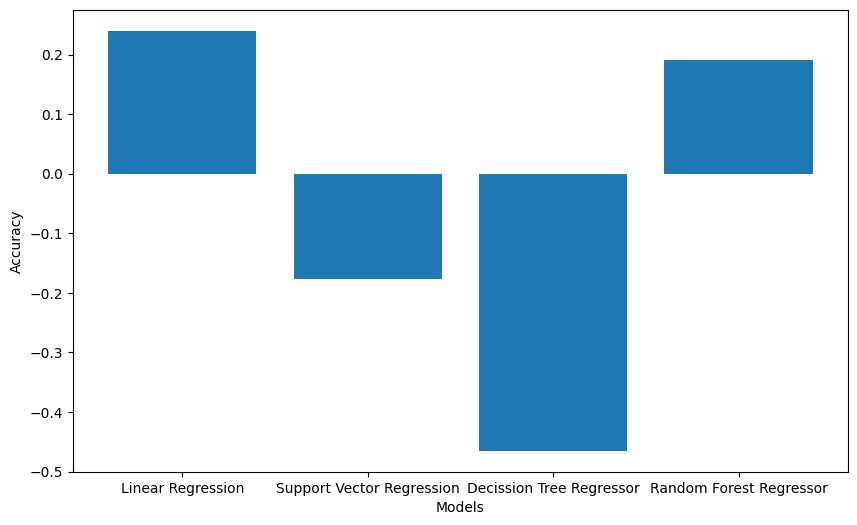

In [41]:
# visuvlize the accuracy with barchat
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Support Vector Regression', 
'Decission Tree Regressor', 'Random Forest Regressor']
acc = [LR_acc, SVR_acc, DT_acc, RF_acc]

plt.figure(figsize=(10,6))
plt.bar(models, acc)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()

In [42]:
#save linear regression model parameters,scalar and onehotencoder
import pickle
pickle.dump(LR_model,open('LR_model.pkl','wb'))
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(encoder,open('encoder.pkl','wb'))



In [43]:
X_train.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,0.217391,0.277628,0.6,1.0,0.0,0.0,0.0,0.0
1,0.565217,0.253369,0.2,1.0,0.0,0.0,0.0,0.0
2,0.739130,0.579515,0.4,0.0,0.0,0.0,1.0,0.0
3,0.978261,0.687332,0.0,1.0,0.0,0.0,1.0,0.0
4,0.630435,0.285714,0.4,0.0,0.0,0.0,0.0,0.0


In [50]:
# use the parameters for new prediction
import pickle
LR_model = pickle.load(open('LR_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))
encoder = pickle.load(open('encoder.pkl', 'rb'))

# new prediction

new_data = pd.DataFrame({'age': [30],
                         'bmi': [20],
                         'children': [2],
                         'sex': ['female'],
                         'smoker': ['no'],
                         'region': ['southwest']})

# encode categorical features
cat_cols = ['sex', 'smoker', 'region']

encoded_new = encoder.transform(new_data[cat_cols])

encoded_cols = encoder.get_feature_names_out(cat_cols)

encoded_new_df = pd.DataFrame(encoded_new, columns=encoded_cols)

# combine numerical + encoded features
new_final = pd.concat([new_data.drop(columns=cat_cols), encoded_new_df], axis=1)

# scale using the saved scaler
new_scaled = scaler.transform(new_final)

# prediction
prediction = LR_model.predict(new_scaled)

print("Predicted Insurance Expense:", prediction[0])

Predicted Insurance Expense: 5512.09455647466
